# Phase 7A Level 2：2RC 三状态 pure DNN 验证

**问题**：在 Level 1S 已通过的基础上，只增加第二个极化时间尺度，pure DNN 是否仍能稳定逼近 MPC？

本实验不包含硬斜率、温度、DFN、扰动或 Phase 5A 压力场。教师审计、双冻结测试和同模型闭环必须同时通过。

## 1. 模型、符号和单位

充电电流 \(I_k\) 为正，状态为

\[
x_k=\begin{bmatrix}SOC_k&V_{1,k}&V_{2,k}\end{bmatrix}^{\mathsf T}.
\]

离散模型为

\[
\begin{aligned}
SOC_{k+1}&=SOC_k+\frac{I_k\Delta t}{3600Q},\\
V_{1,k+1}&=a_1V_{1,k}+R_1(1-a_1)I_k,\\
V_{2,k+1}&=a_2V_{2,k}+R_2(1-a_2)I_k,\\
a_i&=\exp\!\left(-\frac{\Delta t}{\tau_i}\right),\quad i\in\{1,2\},\\
V_{\mathrm{tr},k}&=OCV(SOC_k)+R_0I_k+V_{1,k}+V_{2,k}.
\end{aligned}
\]

其中 \(Q=5\,\mathrm{Ah}\)、\(\Delta t=5\,\mathrm{s}\)，\(R_0,R_1,R_2\) 单位为 \(\Omega\)，\(\tau_1,\tau_2\) 单位为 s。唯一约束为 \(0\le I_k\le10\,\mathrm{A}\) 和 \(V_{\mathrm{tr},k}\le4.20\,\mathrm{V}\)。

## 2. 读取冻结结果

In [1]:
from pathlib import Path
import json, pandas as pd
from IPython.display import display, Image
ROOT=Path.cwd(); OUT=ROOT/'outputs'/'phase7a_level2_2rc'; DATA=ROOT/'data'/'phase7a_level2_2rc'
metrics=json.loads((OUT/'metrics.json').read_text(encoding='utf-8'))
offline=pd.read_csv(OUT/'dnn_offline_metrics.csv'); closed=pd.read_csv(DATA/'closed_loop_metrics.csv'); audit=pd.read_csv(DATA/'multistart_state_summary.csv')
print(metrics['study_name'],metrics['status'])

phase7a_level2_project_2rc_pure_dnn completed


## 3. 全域和末端教师覆盖

,attempted_trajectories,accepted_trajectories,acceptance_fraction,sample_count,low_current_label_count,checks,success
0,400,399,0.9975,5752,171,"{'acceptance': True, 'complete_accepted_trajec...",True


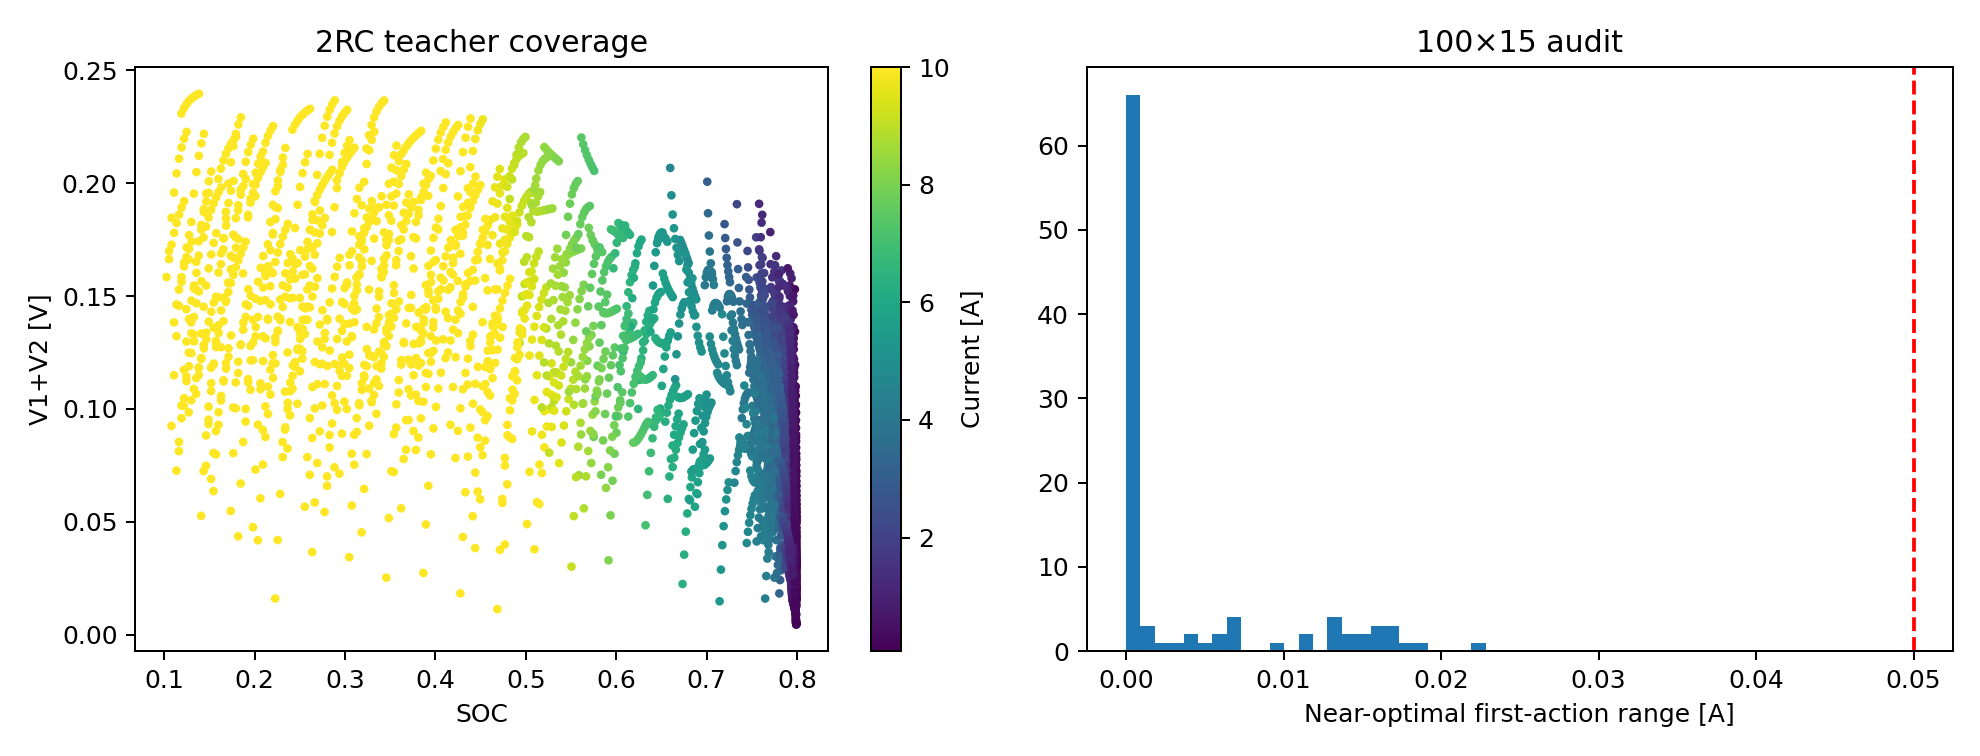

In [2]:
display(pd.DataFrame([metrics['teacher']]))
assert metrics['teacher']['success']
assert metrics['teacher']['attempted_trajectories']==400
assert metrics['teacher']['low_current_label_count']>=100
display(Image(filename=str(OUT/'figures'/'teacher_and_audit.png')))

## 4. 100×15 多起点教师审计

In [3]:
display(pd.DataFrame([metrics['teacher_audit']]))
assert len(audit)==100
assert metrics['teacher_audit']['success']
assert metrics['teacher_audit']['near_optimal_multivalued_fraction']==0

,state_count,warm_starts_per_state,near_optimal_multivalued_fraction,near_optimal_first_action_range_p95_a,maximum_near_optimal_first_action_range_a,checks,success
0,100,15,0.0,0.016914,0.022829,"{'exact_audit_contract': True, 'all_optimizer_...",True


## 5. 深层 LBFGS 五种子双冻结测试

In [4]:
view=offline[['seed','test_nrmse','terminal_test_nrmse','test_bias_a','terminal_test_bias_a']].copy()
view['global_test_nrmse_percent']=100*view.pop('test_nrmse'); view['terminal_test_nrmse_percent']=100*view.pop('terminal_test_nrmse')
display(view)
assert (view.global_test_nrmse_percent<1).all(); assert (view.terminal_test_nrmse_percent<1).all()

,seed,test_bias_a,terminal_test_bias_a,global_test_nrmse_percent,terminal_test_nrmse_percent
0,22,-0.003889,0.002930,0.200339,0.237849
1,42,-0.000945,0.002452,0.273533,0.239731
2,73,-0.003644,0.001587,0.210636,0.204590
3,101,-0.001380,0.003709,0.191825,0.275678
4,137,-0.002886,0.002718,0.253408,0.461984


## 6. 三状态同模型闭环

,seed,target_reach_fraction,maximum_voltage_violation_v,maximum_current_violation_a,speedup,current_nrmse_percent,charge_time_gap_percent
0,22,1.0,0.0,0.0,1342.058964,0.213857,1.343336
1,42,1.0,0.0,0.0,1399.312007,0.189236,1.343336
2,73,1.0,0.0,0.0,1384.369978,0.148416,0.416742
3,101,1.0,0.0,0.0,1413.594198,0.173832,0.880039
4,137,1.0,0.0,0.0,1374.926637,0.366230,0.562342


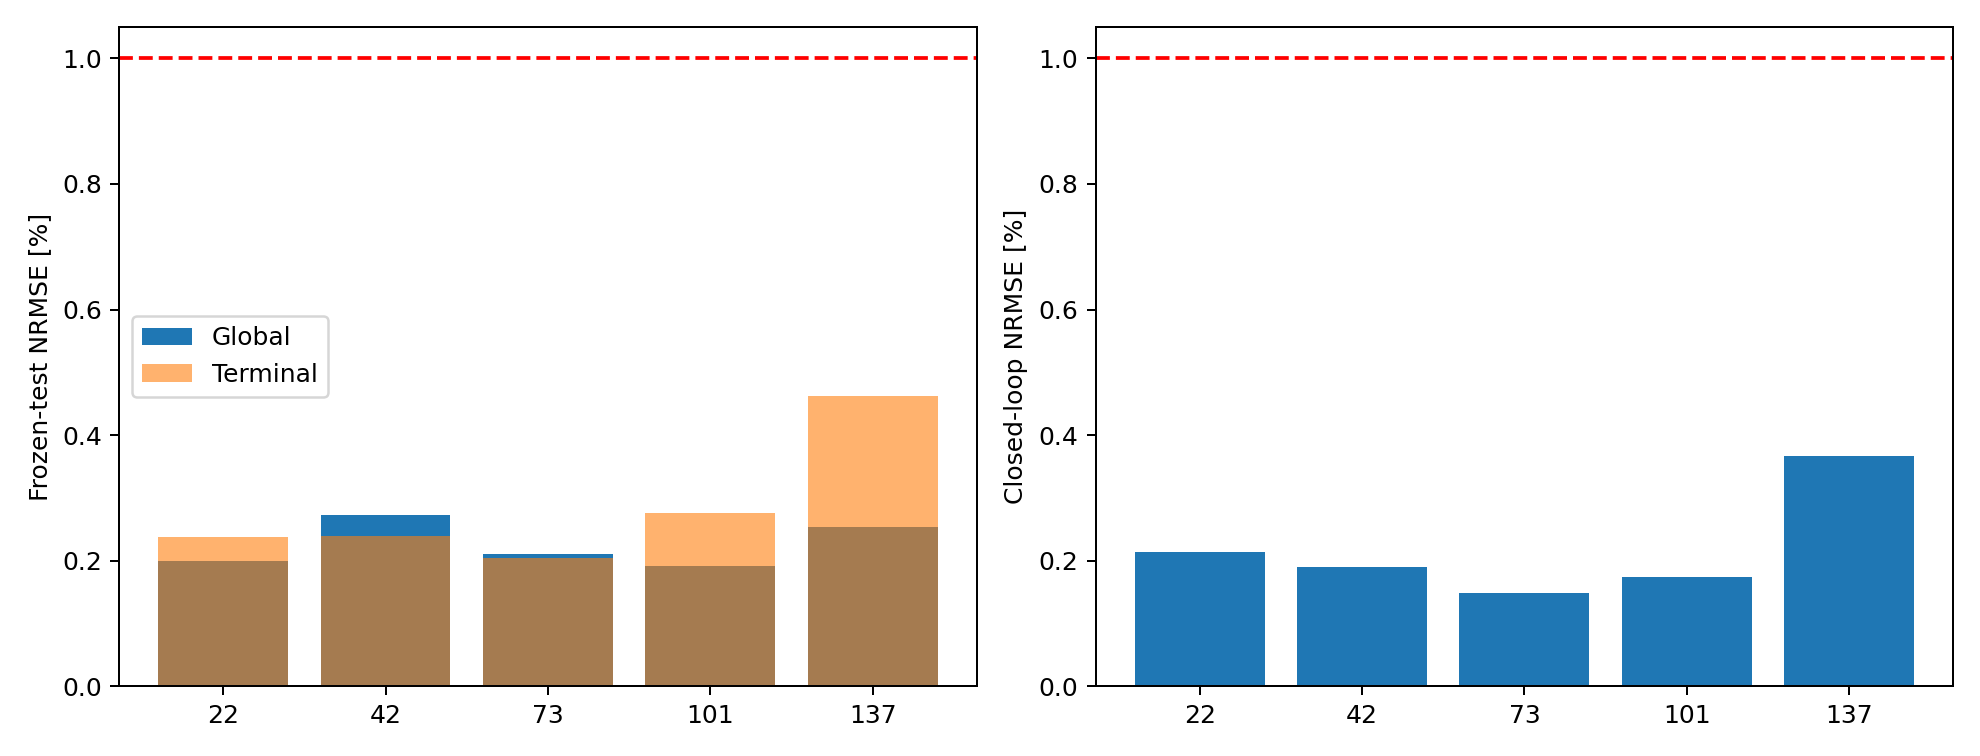

In [5]:
view=closed[['seed','mean_current_nrmse','mean_charge_time_gap_fraction','target_reach_fraction','maximum_voltage_violation_v','maximum_current_violation_a','speedup']].copy()
view['current_nrmse_percent']=100*view.pop('mean_current_nrmse'); view['charge_time_gap_percent']=100*view.pop('mean_charge_time_gap_fraction')
display(view); display(Image(filename=str(OUT/'figures'/'five_seed_validation.png')))
assert (view.current_nrmse_percent<1).all(); assert (view.charge_time_gap_percent<2).all(); assert (view.target_reach_fraction==1).all()
assert (view.maximum_voltage_violation_v==0).all(); assert (view.maximum_current_violation_a==0).all(); assert (view.speedup>100).all()

## 7. 阶段判定

In [6]:
display(pd.DataFrame([metrics['decision']['checks']]))
print(metrics['decision']['conclusion']); print('进入 Level 3:',metrics['decision']['proceed_to_level3'])
assert metrics['decision']['level2_success']; assert metrics['decision']['proceed_to_level3']

,teacher_determinism_passed,dual_offline_tests_passed,same_model_closed_loop_passed
0,True,True,True


Level 2 通过
进入 Level 3: True


## 结论

加入第二极化状态后，教师控制律仍保持确定，深层 LBFGS 五种子在全域、末端和完整闭环中均通过。第二极化时间尺度没有成为 pure DNN 的首次失效因素；下一层只能单独加入上一电流和硬斜率约束。